## Initial Set-up

In [24]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## Iteration 1


### Go emotions

In [ ]:
# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\go_emotions.csv"

# Load the dataset
go_emotions = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(go_emotions.head(5))

Step 1: Dataset loaded successfully. Preview:


,Unnamed: 0,text,emotion,sub emotion,processed_text
0,0,That game hurt.,sadness,sadness,That game hurt .
1,2,"You do right, if you don't care then fuck 'em!",neutral,neutral,"You do right , if you do not care then fuck 'em !"
2,3,Man I love reddit.,happiness,love,Man I love reddit .
3,4,"[NAME] was nowhere near them, he was by the Fa...",neutral,neutral,"[ NAME ] was nowhere near them , he was by the..."
4,5,Right? Considering it’s such an important docu...,happiness,gratitude,Right ? Considering it is such an important do...


In [61]:
# Keep only the relevant columns
go_emotions_clean = go_emotions[['processed_text', 'emotion']].copy()
go_emotions_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(go_emotions_clean.head())

Step 2: Selected relevant columns. Preview:


,text,label
0,That game hurt .,sadness
1,"You do right , if you do not care then fuck 'em !",neutral
2,Man I love reddit .,happiness
3,"[ NAME ] was nowhere near them , he was by the...",neutral
4,Right ? Considering it is such an important do...,happiness


In [62]:
# Step 3: Check for missing values
print("Step 3: Checking for missing values:")
print(go_emotions_clean.isnull().sum())

# Step 4: Drop rows with missing text or label
go_emotions_clean.dropna(subset=['text', 'label'], inplace=True)

# Display result after removal
print(f"Step 4: Removing rows with missing information completed. Dataset size after removal: {len(go_emotions_clean)}")

Step 3: Checking for missing values:
text         0
label    13124
dtype: int64
Step 4: Removing rows with missing information completed. Dataset size after removal: 158696


In [63]:
# Step 5: Encode emotion labels
label_encoder = LabelEncoder()
go_emotions_clean['label_encoded'] = label_encoder.fit_transform(go_emotions_clean['label'])

# Display the first few rows to verify the conversion
print("Step 3: Converted one-hot labels into categorical labels. Preview:")
display(go_emotions_clean[['text', 'label', 'label_encoded']].head())

Step 3: Converted one-hot labels into categorical labels. Preview:


,text,label,label_encoded
0,That game hurt .,sadness,5
1,"You do right , if you do not care then fuck 'em !",neutral,4
2,Man I love reddit .,happiness,3
3,"[ NAME ] was nowhere near them , he was by the...",neutral,4
4,Right ? Considering it is such an important do...,happiness,3


In [64]:
# Split data into training, validation, and testing sets (before vectorization to avoid data leakage)
X_train, X_temp, y_train, y_temp = train_test_split(
    go_emotions_clean['text'].astype(str),  # Text
    go_emotions_clean['label_encoded'],  # Labels
    test_size=0.3, random_state=42, stratify=go_emotions_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Display dataset split details
print(f"Step 5: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Step 5: Data successfully split into training, validation, and testing sets.
Training set size: 111087 samples
Validation set size: 23804 samples
Testing set size: 23805 samples


In [65]:
# Basic TF-IDF vectorizer (very simple baseline)
vectorizer = TfidfVectorizer()

# Convert text data to TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)  # Learn vocab from training data
X_val_tfidf = vectorizer.transform(X_val)  # Transform validation data (no fitting)
X_test_tfidf = vectorizer.transform(X_test)  # Transform test data (no fitting)

# Display feature shapes
print(f"Step 6: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

Step 6: TF-IDF transformation completed. Feature shape (train): (111087, 29203)
Feature shape (validation): (23804, 29203)
Feature shape (test): (23805, 29203)


In [67]:
# Initialize the model
logreg_model = LogisticRegression(max_iter=500, random_state=42)

# Train on training data
logreg_model.fit(X_train_tfidf, y_train)

print("Step 7: Logistic Regression model trained successfully.")

Step 7: Logistic Regression model trained successfully.


In [68]:
# Predict on validation set
y_val_pred = logreg_model.predict(X_val_tfidf)

# Predict on test set
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 8: Model prediction completed for validation and test sets.")

Step 8: Model prediction completed for validation and test sets.


In [69]:
# Validation set evaluation
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Step 9: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Macro F1 Score: {val_f1:.2f}")
print("Validation Classification Report:\n", val_report)

# Test set evaluation
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Step 9: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Macro F1 Score: {test_f1:.2f}")
print("Test Classification Report:\n", test_report)

Step 9: Validation Set Evaluation Completed.
Validation Accuracy: 0.58
Validation Macro F1 Score: 0.41
Validation Classification Report:
               precision    recall  f1-score   support

       angry       0.48      0.30      0.37      3399
     disgust       0.54      0.11      0.18       437
        fear       0.64      0.20      0.30       386
   happiness       0.67      0.70      0.68      9728
     neutral       0.51      0.65      0.57      8295
     sadness       0.59      0.27      0.37      1559

    accuracy                           0.58     23804
   macro avg       0.57      0.37      0.41     23804
weighted avg       0.58      0.58      0.56     23804

Step 9: Test Set Evaluation Completed.
Test Accuracy: 0.58
Test Macro F1 Score: 0.42
Test Classification Report:
               precision    recall  f1-score   support

       angry       0.46      0.29      0.35      3400
     disgust       0.54      0.13      0.21       437
        fear       0.66      0.20      0.3

Step 9: Confusion Matrix for Validation Set
Step 9: Confusion Matrix for Test Set


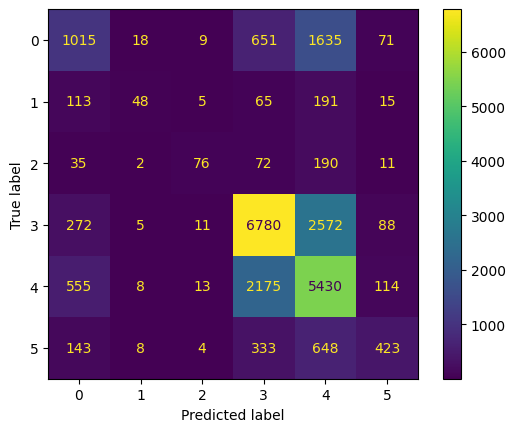

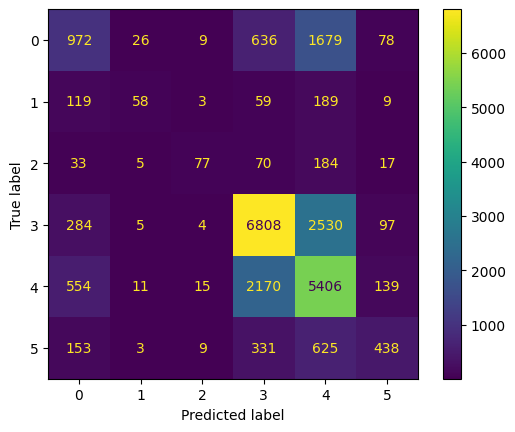

In [70]:
# Display Confusion Matrix for both Validation and Test Sets
print("Step 9: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)

print("Step 9: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)

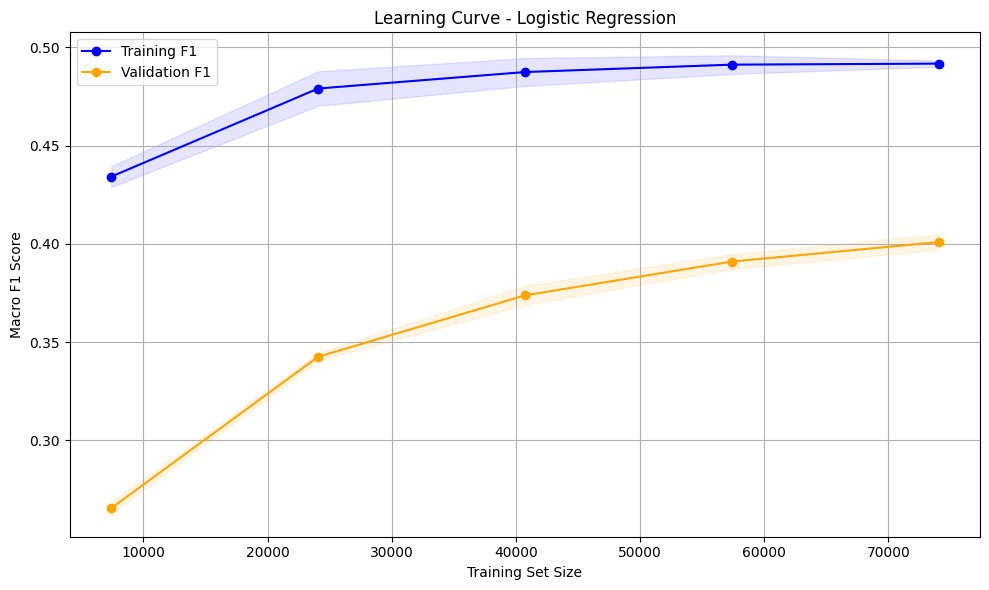

In [71]:
from sklearn.model_selection import learning_curve
import numpy as np

# Step 13: Plot learning curves
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Calculate means and stds
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="blue")

plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.1, color="orange")

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Test


In [74]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("New test dataset loaded successfully. Preview:")
display(df_test.head())

New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


In [75]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("Step 1: New test dataset loaded successfully. Preview:")
display(df_test.head())

# Keep only the relevant columns
df_test_clean = df_test[['processed_text', 'emotion']].copy()
df_test_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm selection
print("Step 2: Selected relevant columns from test dataset. Preview:")
display(df_test_clean.head())

# Handle Missing Values (if any)
print("Step 3: Checking for missing values in test data:")
print(df_test_clean.isnull().sum())
df_test_clean.dropna(subset=['text', 'label'], inplace=True)

print(f"Remaining test rows after dropping missing: {len(df_test_clean)}")

# Encode emotion labels using the same label encoder used in training
df_test_clean['label_encoded'] = label_encoder.transform(df_test_clean['label'])

# Display preview after label encoding
print("Step 4: Converted one-hot labels into categorical labels. Preview:")
display(df_test_clean[['text', 'label', 'label_encoded']].head())

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_tfidf = vectorizer.transform(df_test_clean['text'].astype(str))

# Make Predictions Using the Trained Logistic Regression Model
y_test_pred = logreg_model.predict(X_test_tfidf)

# Evaluate Model Performance on Test Data
accuracy_test = accuracy_score(df_test_clean['label_encoded'], y_test_pred)
f1_test = f1_score(df_test_clean['label_encoded'], y_test_pred, average='macro')

print(f"Test Dataset Accuracy: {accuracy_test:.2f}")
print(f"Test Dataset Macro F1 Score: {f1_test:.2f}")

# Generate classification report
print("Classification Report on Test Data:\n")
print(classification_report(df_test_clean['label_encoded'], y_test_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for Test Data:")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, df_test_clean['label_encoded'])
plt.show()

Step 1: New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


Step 2: Selected relevant columns from test dataset. Preview:


,text,label
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness
1,Thousands of model hopefuls from all over Asia...,happiness
2,But only the standout modeling talent were cho...,happiness
3,Prepare for an adventure of a lifetime,happiness
4,All I can say girls for this fierce fifth seas...,happiness


Step 3: Checking for missing values in test data:
text     0
label    0
dtype: int64
Remaining test rows after dropping missing: 860


ValueError: y contains previously unseen labels: 'surprise'

### Friends

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,also I was the point person on my company’s tr...,neutral,6,also I was the point person on my company’s tr...
1,You must’ve had your hands full.,neutral,6,You must have had your hands full .
2,That I did. That I did.,neutral,6,That I did . That I did .
3,So let’s talk a little bit about your duties.,neutral,6,So let us talk a little bit about your duties .
4,My duties? All right.,surprise,4,My duties ? All right .


Step 2: Selected relevant columns. Preview:


,text,label
0,also I was the point person on my company’s tr...,neutral
1,You must have had your hands full .,neutral
2,That I did . That I did .,neutral
3,So let us talk a little bit about your duties .,neutral
4,My duties ? All right .,surprise


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing rows with missing information completed. Dataset size after removal: 12158
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,also I was the point person on my company’s tr...,neutral,4
1,You must have had your hands full .,neutral,4
2,That I did . That I did .,neutral,4
3,So let us talk a little bit about your duties .,neutral,4
4,My duties ? All right .,surprise,6


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 8510 samples
Validation set size: 1824 samples
Testing set size: 1824 samples
Step 7: TF-IDF transformation completed. Feature shape (train): (8510, 5164)
Feature shape (validation): (1824, 5164)
Feature shape (test): (1824, 5164)
Step 8: Logistic Regression model trained successfully.
Step 9: Model prediction completed for validation and test sets.
Step 10: Validation Set Evaluation Completed.
Validation Accuracy: 0.52
Validation Macro F1 Score: 0.26
Validation Classification Report:
               precision    recall  f1-score   support

       anger       0.27      0.08      0.12       225
     disgust       1.00      0.02      0.04        52
        fear       1.00      0.02      0.04        52
   happiness       0.58      0.24      0.34       306
     neutral       0.53      0.92      0.67       849
     sadness       0.53      0.13      0.21       143
    surprise       0.56      0.30 

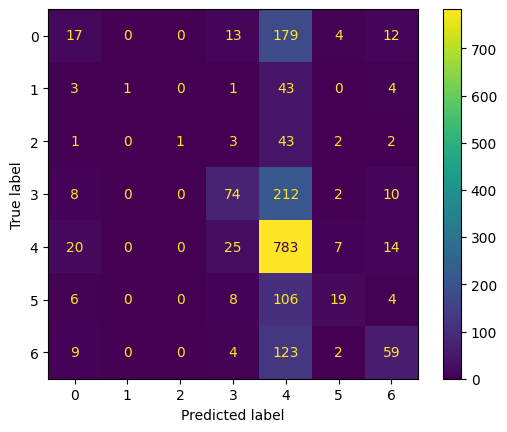

Step 12: Confusion Matrix for Test Set


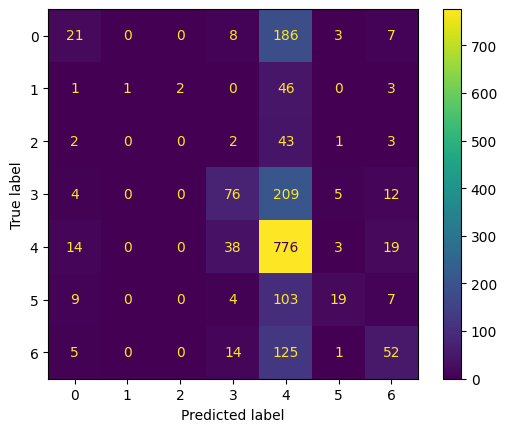

Step 13: Plot the Learning Curve


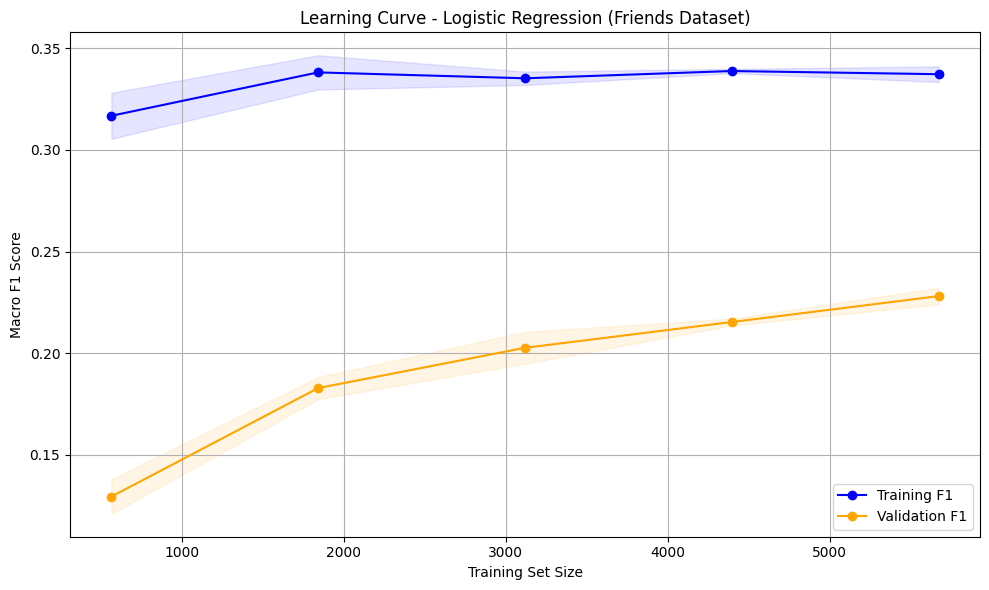

In [77]:
# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends.csv"

# Load the dataset
friends = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends.head(5))

# Keep only the relevant columns
friends_clean = friends[['processed_text', 'emotion']].copy()
friends_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean.isnull().sum())

# Drop rows with missing text or label
friends_clean.dropna(subset=['text', 'label'], inplace=True)

# Display result after removal
print(f"Step 4: Removing rows with missing information completed. Dataset size after removal: {len(friends_clean)}")

# Encode emotion labels
label_encoder = LabelEncoder()
friends_clean['label_encoded'] = label_encoder.fit_transform(friends_clean['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean['text'].astype(str),
    friends_clean['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Basic TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Convert text data to TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Display feature shapes
print(f"Step 7: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

# Initialize the model
logreg_model = LogisticRegression(max_iter=500, random_state=42)

# Train on training data
logreg_model.fit(X_train_tfidf, y_train)

print("Step 8: Logistic Regression model trained successfully.")

# Predict on validation set
y_val_pred = logreg_model.predict(X_val_tfidf)

# Predict on test set
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 9: Model prediction completed for validation and test sets.")

# Validation set evaluation
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Step 10: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Macro F1 Score: {val_f1:.2f}")
print("Validation Classification Report:\n", val_report)

# Test set evaluation
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Step 11: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Macro F1 Score: {test_f1:.2f}")
print("Test Classification Report:\n", test_report)

# Confusion Matrix - Validation Set
print("Step 12: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)
plt.show()

# Confusion Matrix - Test Set
print("Step 12: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)
plt.show()

# Step 13: Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Means and stds
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot learning curve
print("Step 13: Plot the Learning Curve")
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
plt.title("Learning Curve - Logistic Regression (Friends Dataset)")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Test

Step 1: New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


Step 2: Selected relevant columns from test dataset. Preview:


,text,label
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness
1,Thousands of model hopefuls from all over Asia...,happiness
2,But only the standout modeling talent were cho...,happiness
3,Prepare for an adventure of a lifetime,happiness
4,All I can say girls for this fierce fifth seas...,happiness


Step 3: Checking for missing values in test data:
text     0
label    0
dtype: int64
Remaining test rows after dropping missing: 860
Step 4: Converted one-hot labels into categorical labels. Preview:


,text,label,label_encoded
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,3
1,Thousands of model hopefuls from all over Asia...,happiness,3
2,But only the standout modeling talent were cho...,happiness,3
3,Prepare for an adventure of a lifetime,happiness,3
4,All I can say girls for this fierce fifth seas...,happiness,3


Test Dataset Accuracy: 0.40
Test Dataset Macro F1 Score: 0.20
Classification Report on Test Data:

              precision    recall  f1-score   support

       anger       0.17      0.09      0.12        53
     disgust       0.00      0.00      0.00         1
        fear       1.00      0.00      0.00        38
   happiness       0.81      0.17      0.28       391
     neutral       0.36      0.92      0.52       276
     sadness       0.10      0.02      0.03        65
    surprise       0.52      0.36      0.43        36

    accuracy                           0.40       860
   macro avg       0.42      0.22      0.20       860
weighted avg       0.57      0.40      0.32       860

Confusion Matrix for Test Data:


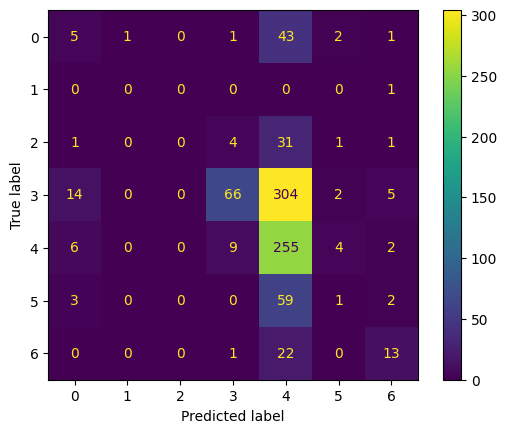

In [78]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("Step 1: New test dataset loaded successfully. Preview:")
display(df_test.head())

# Keep only the relevant columns
df_test_clean = df_test[['processed_text', 'emotion']].copy()
df_test_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm selection
print("Step 2: Selected relevant columns from test dataset. Preview:")
display(df_test_clean.head())

# Handle Missing Values (if any)
print("Step 3: Checking for missing values in test data:")
print(df_test_clean.isnull().sum())
df_test_clean.dropna(subset=['text', 'label'], inplace=True)

print(f"Remaining test rows after dropping missing: {len(df_test_clean)}")

# Encode emotion labels using the same label encoder used in training
df_test_clean['label_encoded'] = label_encoder.transform(df_test_clean['label'])

# Display preview after label encoding
print("Step 4: Converted one-hot labels into categorical labels. Preview:")
display(df_test_clean[['text', 'label', 'label_encoded']].head())

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_tfidf = vectorizer.transform(df_test_clean['text'].astype(str))

# Make Predictions Using the Trained Logistic Regression Model
y_test_pred = logreg_model.predict(X_test_tfidf)

# Evaluate Model Performance on Test Data
accuracy_test = accuracy_score(df_test_clean['label_encoded'], y_test_pred)
f1_test = f1_score(df_test_clean['label_encoded'], y_test_pred, average='macro')

print(f"Test Dataset Accuracy: {accuracy_test:.2f}")
print(f"Test Dataset Macro F1 Score: {f1_test:.2f}")

# Generate classification report
print("Classification Report on Test Data:\n")
print(classification_report(df_test_clean['label_encoded'], y_test_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for Test Data:")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, df_test_clean['label_encoded'])
plt.show()

### Friends balanced

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing rows with missing information completed. Dataset size after removal: 10500
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples
Step 7: TF-IDF transformation completed. Feature shape (train): (7350, 3899)
Feature shape (validation): (1575, 3899)
Feature shape (test): (1575, 3899)
Step 8: Logistic Regression model trained successfully.
Step 9: Model prediction completed for validation and test sets.
Step 10: Validation Set Evaluation Completed.
Validation Accuracy: 0.54
Validation Macro F1 Score: 0.53
Validation Classification Report:
               precision    recall  f1-score   support

       anger       0.40      0.31      0.35       225
     disgust       0.65      0.74      0.69       225
        fear       0.67      0.78      0.72       225
   happiness       0.48      0.46      0.47       225
     neutral       0.31      0.27      0.29       225
     sadness       0.58      0.64      0.61       225
    surprise       0.56      0.56 

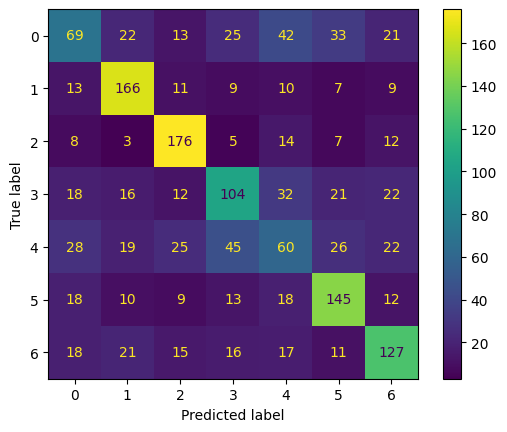

Step 12: Confusion Matrix for Test Set


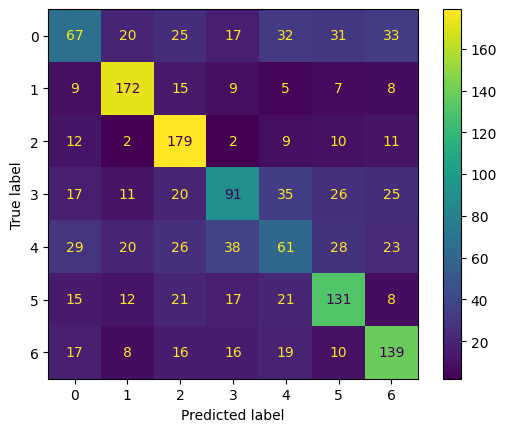

Step 13: Plot the Learning Curve


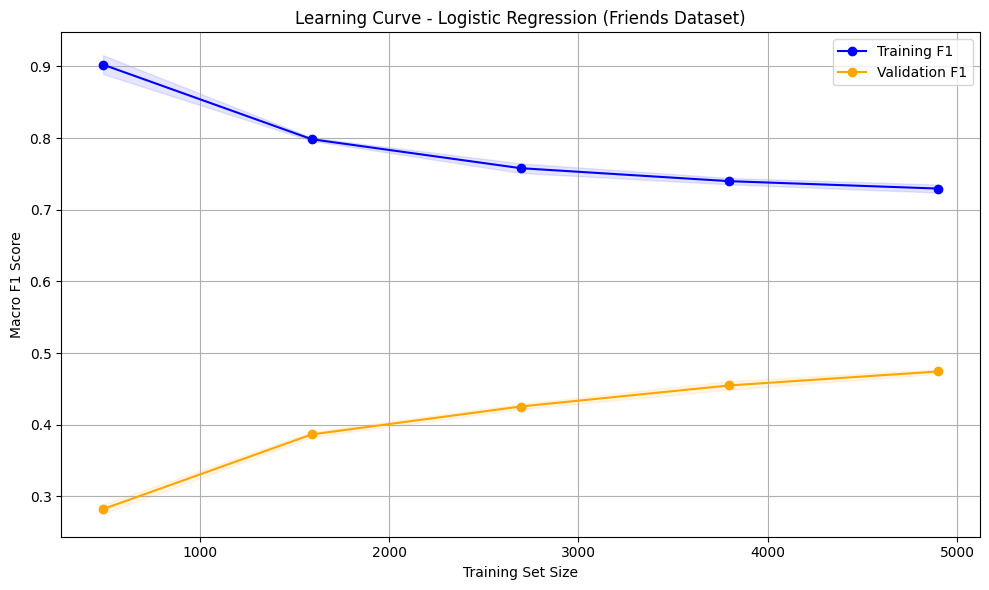

In [ ]:
# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load the dataset
friends = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends.head())

# Keep only the relevant columns
friends_clean = friends[['processed_text', 'emotion']].copy()
friends_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean.isnull().sum())

# Drop rows with missing text or label
friends_clean.dropna(subset=['text', 'label'], inplace=True)

# Display result after removal
print(f"Step 4: Removing rows with missing information completed. Dataset size after removal: {len(friends_clean)}")

# Encode emotion labels
label_encoder = LabelEncoder()
friends_clean['label_encoded'] = label_encoder.fit_transform(friends_clean['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean['text'].astype(str),
    friends_clean['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Basic TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Convert text data to TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Display feature shapes
print(f"Step 7: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

# Initialize the model
logreg_model = LogisticRegression(max_iter=500, random_state=42)

# Train on training data
logreg_model.fit(X_train_tfidf, y_train)

print("Step 8: Logistic Regression model trained successfully.")

# Predict on validation set
y_val_pred = logreg_model.predict(X_val_tfidf)

# Predict on test set
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 9: Model prediction completed for validation and test sets.")

# Validation set evaluation
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Step 10: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Macro F1 Score: {val_f1:.2f}")
print("Validation Classification Report:\n", val_report)

# Test set evaluation
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Step 11: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Macro F1 Score: {test_f1:.2f}")
print("Test Classification Report:\n", test_report)

# Confusion Matrix - Validation Set
print("Step 12: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)
plt.show()

# Confusion Matrix - Test Set
print("Step 12: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)
plt.show()

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Means and stds
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot learning curve
print("Step 13: Plot the Learning Curve")
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
plt.title("Learning Curve - Logistic Regression (Friends Dataset)")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Test

Step 1: New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


Step 2: Selected relevant columns from test dataset. Preview:


,text,label
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness
1,Thousands of model hopefuls from all over Asia...,happiness
2,But only the standout modeling talent were cho...,happiness
3,Prepare for an adventure of a lifetime,happiness
4,All I can say girls for this fierce fifth seas...,happiness


Step 3: Checking for missing values in test data:
text     0
label    0
dtype: int64
Remaining test rows after dropping missing: 860
Step 4: Converted one-hot labels into categorical labels. Preview:


,text,label,label_encoded
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,3
1,Thousands of model hopefuls from all over Asia...,happiness,3
2,But only the standout modeling talent were cho...,happiness,3
3,Prepare for an adventure of a lifetime,happiness,3
4,All I can say girls for this fierce fifth seas...,happiness,3


Test Dataset Accuracy: 0.34
Test Dataset Macro F1 Score: 0.25
Classification Report on Test Data:

              precision    recall  f1-score   support

       anger       0.12      0.34      0.17        53
     disgust       0.00      0.00      0.00         1
        fear       0.21      0.32      0.25        38
   happiness       0.68      0.32      0.43       391
     neutral       0.46      0.38      0.42       276
     sadness       0.14      0.22      0.17        65
    surprise       0.25      0.42      0.31        36

    accuracy                           0.34       860
   macro avg       0.27      0.28      0.25       860
weighted avg       0.50      0.34      0.38       860

Confusion Matrix for Test Data:


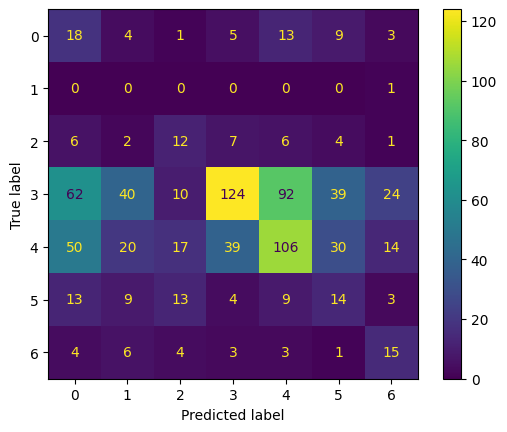

In [80]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("Step 1: New test dataset loaded successfully. Preview:")
display(df_test.head())

# Keep only the relevant columns
df_test_clean = df_test[['processed_text', 'emotion']].copy()
df_test_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm selection
print("Step 2: Selected relevant columns from test dataset. Preview:")
display(df_test_clean.head())

# Handle Missing Values (if any)
print("Step 3: Checking for missing values in test data:")
print(df_test_clean.isnull().sum())
df_test_clean.dropna(subset=['text', 'label'], inplace=True)

print(f"Remaining test rows after dropping missing: {len(df_test_clean)}")

# Encode emotion labels using the same label encoder used in training
df_test_clean['label_encoded'] = label_encoder.transform(df_test_clean['label'])

# Display preview after label encoding
print("Step 4: Converted one-hot labels into categorical labels. Preview:")
display(df_test_clean[['text', 'label', 'label_encoded']].head())

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_tfidf = vectorizer.transform(df_test_clean['text'].astype(str))

# Make Predictions Using the Trained Logistic Regression Model
y_test_pred = logreg_model.predict(X_test_tfidf)

# Evaluate Model Performance on Test Data
accuracy_test = accuracy_score(df_test_clean['label_encoded'], y_test_pred)
f1_test = f1_score(df_test_clean['label_encoded'], y_test_pred, average='macro')

print(f"Test Dataset Accuracy: {accuracy_test:.2f}")
print(f"Test Dataset Macro F1 Score: {f1_test:.2f}")

# Generate classification report
print("Classification Report on Test Data:\n")
print(classification_report(df_test_clean['label_encoded'], y_test_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for Test Data:")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, df_test_clean['label_encoded'])
plt.show()

### Groups datasets

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub_emotion,processed_text
0,Did you kiss?,surprise,4,curiosity,Did you kiss ?
1,Yeah.,neutral,6,neutral,Yeah .
2,But no !,anger,2,annoyance,But no !
3,Why do you have a problem?,surprise,4,confusion,Why do you have a problem ?
4,Did you kiss?,surprise,4,curiosity,Did you kiss ?


Step 2: Selected relevant columns. Preview:


,text,label
0,Did you kiss ?,surprise
1,Yeah .,neutral
2,But no !,anger
3,Why do you have a problem ?,surprise
4,Did you kiss ?,surprise


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing rows with missing information completed. Dataset size after removal: 24295
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,Did you kiss ?,surprise,6
1,Yeah .,neutral,4
2,But no !,anger,0
3,Why do you have a problem ?,surprise,6
4,Did you kiss ?,surprise,6


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 17006 samples
Validation set size: 3644 samples
Testing set size: 3645 samples
Step 7: TF-IDF transformation completed. Feature shape (train): (17006, 7705)
Feature shape (validation): (3644, 7705)
Feature shape (test): (3645, 7705)
Step 8: Logistic Regression model trained successfully.
Step 9: Model prediction completed for validation and test sets.
Step 10: Validation Set Evaluation Completed.
Validation Accuracy: 0.61
Validation Macro F1 Score: 0.32
Validation Classification Report:
               precision    recall  f1-score   support

       anger       0.50      0.13      0.21       221
     disgust       1.00      0.00      0.00        23
        fear       0.62      0.07      0.12       117
   happiness       0.62      0.30      0.40       489
     neutral       0.61      0.86      0.71      1766
     sadness       0.62      0.14      0.22       148
    surprise       0.61      0.5

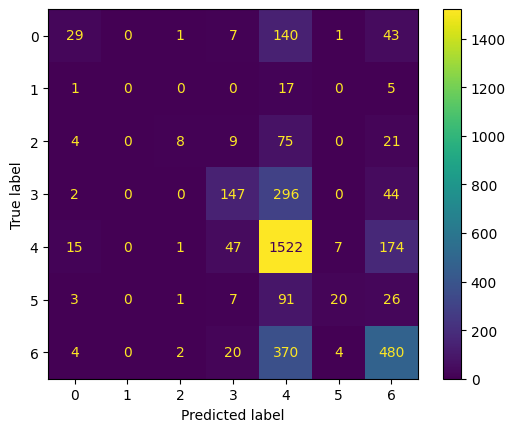

Step 12: Confusion Matrix for Test Set


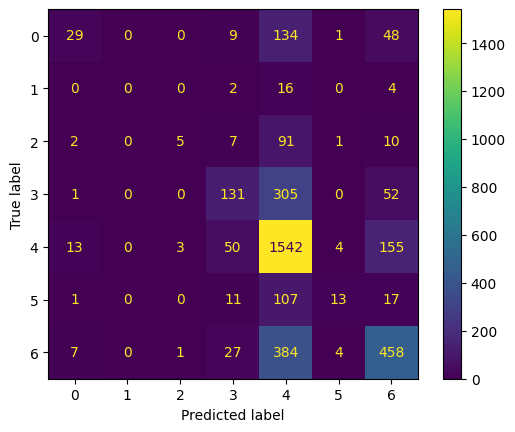

Step 13: Plot the Learning Curve


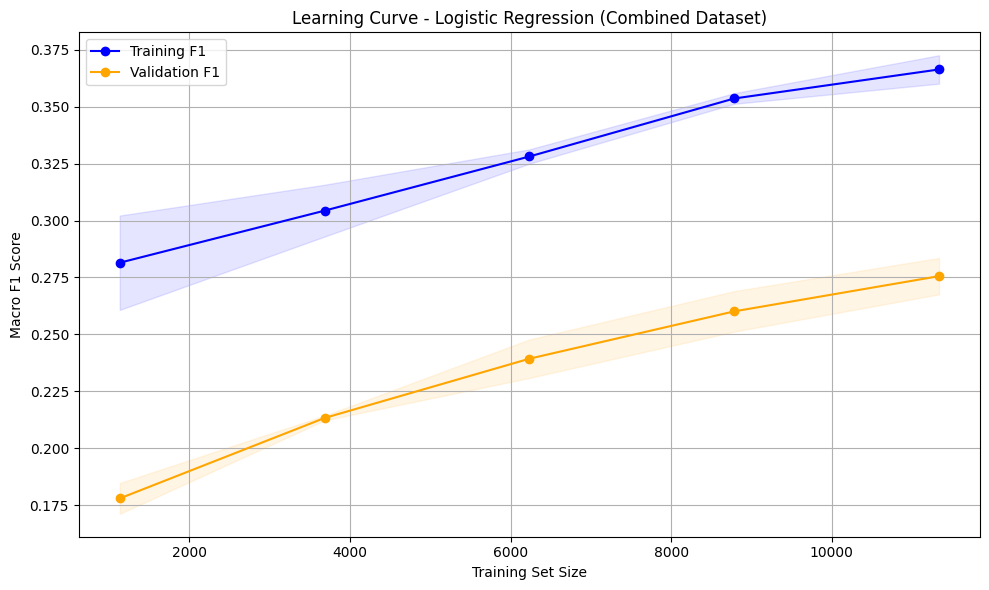

In [83]:
# File path
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\groups.csv"

groups_combined = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(groups_combined.head())

# Keep only the relevant columns
groups_combined_clean = groups_combined[['processed_text', 'emotion']].copy()
groups_combined_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(groups_combined_clean.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(groups_combined_clean.isnull().sum())

# Drop rows with missing text or label
groups_combined_clean.dropna(subset=['text', 'label'], inplace=True)
print(f"Step 4: Removing rows with missing information completed. Dataset size after removal: {len(groups_combined_clean)}")

# Encode emotion labels
label_encoder = LabelEncoder()
groups_combined_clean['label_encoded'] = label_encoder.fit_transform(groups_combined_clean['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(groups_combined_clean[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    groups_combined_clean['text'].astype(str),
    groups_combined_clean['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=groups_combined_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Basic TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Convert text data to TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Display feature shapes
print(f"Step 7: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

# Initialize the model
logreg_model = LogisticRegression(max_iter=500, random_state=42)

# Train on training data
logreg_model.fit(X_train_tfidf, y_train)

print("Step 8: Logistic Regression model trained successfully.")

# Predict on validation set
y_val_pred = logreg_model.predict(X_val_tfidf)

# Predict on test set
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 9: Model prediction completed for validation and test sets.")

# Validation set evaluation
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Step 10: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Macro F1 Score: {val_f1:.2f}")
print("Validation Classification Report:\n", val_report)

# Test set evaluation
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Step 11: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Macro F1 Score: {test_f1:.2f}")
print("Test Classification Report:\n", test_report)

# Confusion Matrix - Validation Set
print("Step 12: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)
plt.show()

# Confusion Matrix - Test Set
print("Step 12: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)
plt.show()

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Means and stds
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot learning curve
print("Step 13: Plot the Learning Curve")
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
plt.title("Learning Curve - Logistic Regression (Combined Dataset)")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Test

Step 1: New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


Step 2: Selected relevant columns from test dataset. Preview:


,text,label
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness
1,Thousands of model hopefuls from all over Asia...,happiness
2,But only the standout modeling talent were cho...,happiness
3,Prepare for an adventure of a lifetime,happiness
4,All I can say girls for this fierce fifth seas...,happiness


Step 3: Checking for missing values in test data:
text     0
label    0
dtype: int64
Remaining test rows after dropping missing: 860
Step 4: Converted one-hot labels into categorical labels. Preview:


,text,label,label_encoded
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,3
1,Thousands of model hopefuls from all over Asia...,happiness,3
2,But only the standout modeling talent were cho...,happiness,3
3,Prepare for an adventure of a lifetime,happiness,3
4,All I can say girls for this fierce fifth seas...,happiness,3


Test Dataset Accuracy: 0.38
Test Dataset Macro F1 Score: 0.19
Classification Report on Test Data:

              precision    recall  f1-score   support

       anger       0.40      0.11      0.18        53
     disgust       1.00      0.00      0.00         1
        fear       1.00      0.08      0.15        38
   happiness       0.73      0.22      0.34       391
     neutral       0.38      0.78      0.51       276
     sadness       0.50      0.02      0.03        65
    surprise       0.10      0.42      0.16        36

    accuracy                           0.38       860
   macro avg       0.59      0.23      0.19       860
weighted avg       0.56      0.38      0.34       860

Confusion Matrix for Test Data:


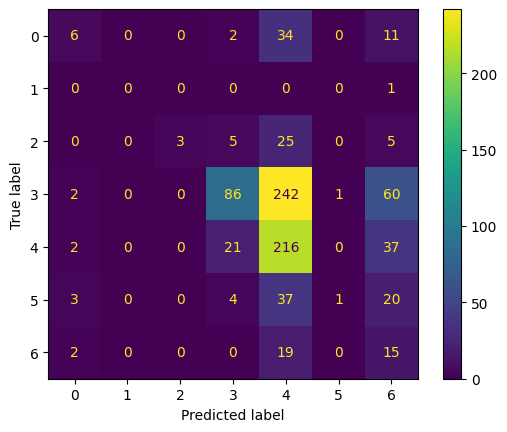

In [84]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("Step 1: New test dataset loaded successfully. Preview:")
display(df_test.head())

# Keep only the relevant columns
df_test_clean = df_test[['processed_text', 'emotion']].copy()
df_test_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm selection
print("Step 2: Selected relevant columns from test dataset. Preview:")
display(df_test_clean.head())

# Handle Missing Values (if any)
print("Step 3: Checking for missing values in test data:")
print(df_test_clean.isnull().sum())
df_test_clean.dropna(subset=['text', 'label'], inplace=True)

print(f"Remaining test rows after dropping missing: {len(df_test_clean)}")

# Encode emotion labels using the same label encoder used in training
df_test_clean['label_encoded'] = label_encoder.transform(df_test_clean['label'])

# Display preview after label encoding
print("Step 4: Converted one-hot labels into categorical labels. Preview:")
display(df_test_clean[['text', 'label', 'label_encoded']].head())

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_tfidf = vectorizer.transform(df_test_clean['text'].astype(str))

# Make Predictions Using the Trained Logistic Regression Model
y_test_pred = logreg_model.predict(X_test_tfidf)

# Evaluate Model Performance on Test Data
accuracy_test = accuracy_score(df_test_clean['label_encoded'], y_test_pred)
f1_test = f1_score(df_test_clean['label_encoded'], y_test_pred, average='macro')

print(f"Test Dataset Accuracy: {accuracy_test:.2f}")
print(f"Test Dataset Macro F1 Score: {f1_test:.2f}")

# Generate classification report
print("Classification Report on Test Data:\n")
print(classification_report(df_test_clean['label_encoded'], y_test_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for Test Data:")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, df_test_clean['label_encoded'])
plt.show()

## Iteration 2 - TF-IDF Parameters Tuning

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removed rows with missing values. Remaining dataset size: 10500
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples

=== Config 1/36 ===
TF-IDF Params: {'ngram_range': (1, 1), 'max_features': 5000, 'stop_words': None}
Model trained. Predicting...
Validation Accuracy: 0.54
Validation Macro F1 Score: 0.53
Classification Report:
               precision    recall  f1-score   support

       anger       0.40      0.31      0.35       225
     disgust       0.65      0.74      0.69       225
        fear       0.67      0.78      0.72       225
   happiness       0.48      0.46      0.47       225
     neutral       0.31      0.27      0.29       225
     sadness       0.58      0.64      0.61       225
    surprise       0.56      0.56      0.56       225

    accuracy                           0.54      1575
   macro avg       0.52      0.54      0.53      1575
weighted avg       0.52      0.54      0.53      1575


=== Config 2/36

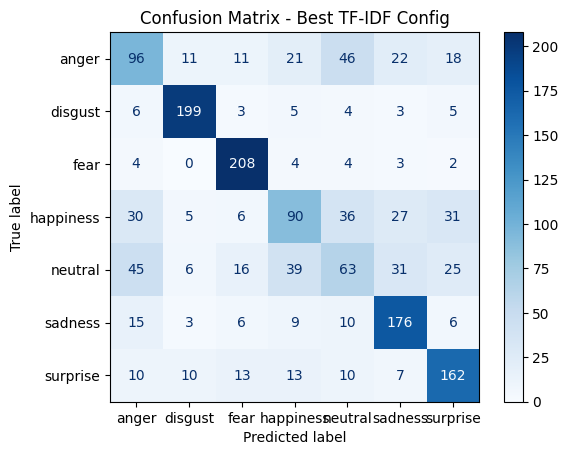

In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# File path
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load dataset
friends = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends.head())

# Keep only relevant columns
friends_clean = friends[['processed_text', 'emotion']].copy()
friends_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean.isnull().sum())

# Drop rows with missing text or label
friends_clean.dropna(subset=['text', 'label'], inplace=True)
print(f"Step 4: Removed rows with missing values. Remaining dataset size: {len(friends_clean)}")

# Encode emotion labels
label_encoder = LabelEncoder()
friends_clean['label_encoded'] = label_encoder.fit_transform(friends_clean['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean['text'].astype(str),
    friends_clean['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Define TF-IDF configurations to test
ngram_ranges = [(1, 1), (1, 2), (1, 3)]
max_features_list = [5000, 10000, 15000, 20000, 25000, 50000]
stop_words_options = [None, 'english']

tfidf_configs = [
    {'ngram_range': n, 'max_features': m, 'stop_words': s}
    for n in ngram_ranges for m in max_features_list for s in stop_words_options
]

results = []

# Evaluate each configuration
for i, config in enumerate(tfidf_configs):
    print(f"\n=== Config {i+1}/{len(tfidf_configs)} ===")
    print(f"TF-IDF Params: {config}")

    vectorizer = TfidfVectorizer(**config)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_val_tfidf = vectorizer.transform(X_val)

    logreg_model = LogisticRegression(max_iter=500, random_state=42)
    logreg_model.fit(X_train_tfidf, y_train)

    print("Model trained. Predicting...")
    y_val_pred = logreg_model.predict(X_val_tfidf)

    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='macro')

    val_report = classification_report(
        y_val, y_val_pred,
        labels=sorted(set(y_val) | set(y_val_pred)),
        target_names=label_encoder.inverse_transform(sorted(set(y_val) | set(y_val_pred))),
        zero_division=1
    )

    print(f"Validation Accuracy: {val_accuracy:.2f}")
    print(f"Validation Macro F1 Score: {val_f1:.2f}")
    print("Classification Report:\n", val_report)

    results.append({
        'config': config,
        'f1': val_f1,
        'accuracy': val_accuracy,
        'model': logreg_model,
        'vectorizer': vectorizer
    })

# Identify best configuration
best_result = max(results, key=lambda x: x['f1'])
best_index = results.index(best_result)
print("\n=== Best TF-IDF Configuration ===")
print(f"Config {best_index + 1} | Macro F1: {best_result['f1']:.4f} | Accuracy: {best_result['accuracy']:.4f}")
print(f"Params: {best_result['config']}")

# Confusion Matrix for Best Model
ConfusionMatrixDisplay.from_estimator(
    best_result['model'],
    best_result['vectorizer'].transform(X_val),
    y_val,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)
plt.title("Confusion Matrix - Best TF-IDF Config")
plt.show()

In [88]:
# Print all TF-IDF results
print("\n=== All TF-IDF Configuration Results ===")
for idx, result in enumerate(results):
    print(f"Config {idx + 1} | Macro F1: {result['f1']:.4f} | Accuracy: {result['accuracy']:.4f}")
    print(f"Params: {result['config']}\n")


=== All TF-IDF Configuration Results ===
Config 1 | Macro F1: 0.5276 | Accuracy: 0.5378
Params: {'ngram_range': (1, 1), 'max_features': 5000, 'stop_words': None}

Config 2 | Macro F1: 0.5110 | Accuracy: 0.5156
Params: {'ngram_range': (1, 1), 'max_features': 5000, 'stop_words': 'english'}

Config 3 | Macro F1: 0.5276 | Accuracy: 0.5378
Params: {'ngram_range': (1, 1), 'max_features': 10000, 'stop_words': None}

Config 4 | Macro F1: 0.5110 | Accuracy: 0.5156
Params: {'ngram_range': (1, 1), 'max_features': 10000, 'stop_words': 'english'}

Config 5 | Macro F1: 0.5276 | Accuracy: 0.5378
Params: {'ngram_range': (1, 1), 'max_features': 15000, 'stop_words': None}

Config 6 | Macro F1: 0.5110 | Accuracy: 0.5156
Params: {'ngram_range': (1, 1), 'max_features': 15000, 'stop_words': 'english'}

Config 7 | Macro F1: 0.5276 | Accuracy: 0.5378
Params: {'ngram_range': (1, 1), 'max_features': 20000, 'stop_words': None}

Config 8 | Macro F1: 0.5110 | Accuracy: 0.5156
Params: {'ngram_range': (1, 1), 'max_

### Train the model with the best configuration

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing rows with missing information completed. Dataset size after removal: 10500
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples
Step 7: TF-IDF transformation completed. Feature shape (train): (7350, 50000)
Feature shape (validation): (1575, 50000)
Feature shape (test): (1575, 50000)
Step 8: Logistic Regression model trained successfully.
Step 9: Model prediction completed for validation and test sets.
Step 10: Validation Set Evaluation Completed.
Validation Accuracy: 0.63
Validation Macro F1 Score: 0.62
Validation Classification Report:
               precision    recall  f1-score   support

       anger       0.47      0.43      0.45       225
     disgust       0.85      0.88      0.87       225
        fear       0.79      0.92      0.85       225
   happiness       0.50      0.40      0.44       225
     neutral       0.36      0.28      0.32       225
     sadness       0.65      0.78      0.71       225
    surprise       0.65      0.

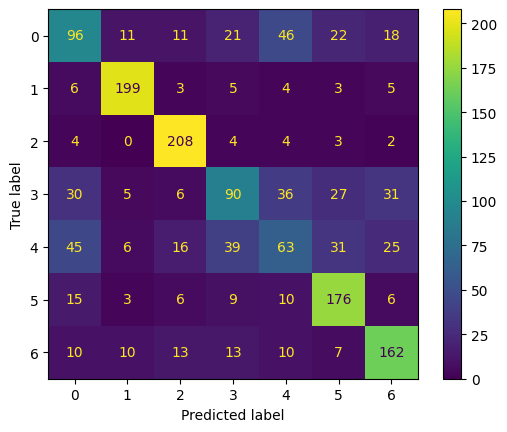

Step 12: Confusion Matrix for Test Set


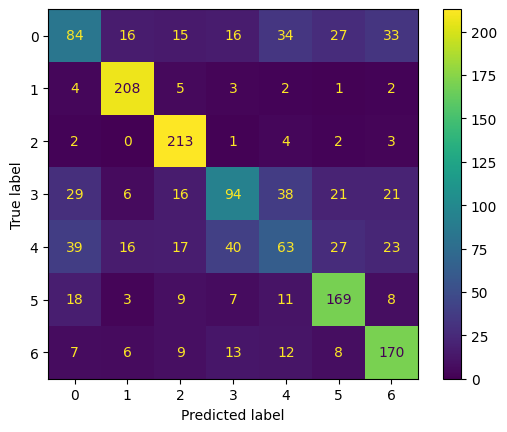

Step 13: Plot the Learning Curve


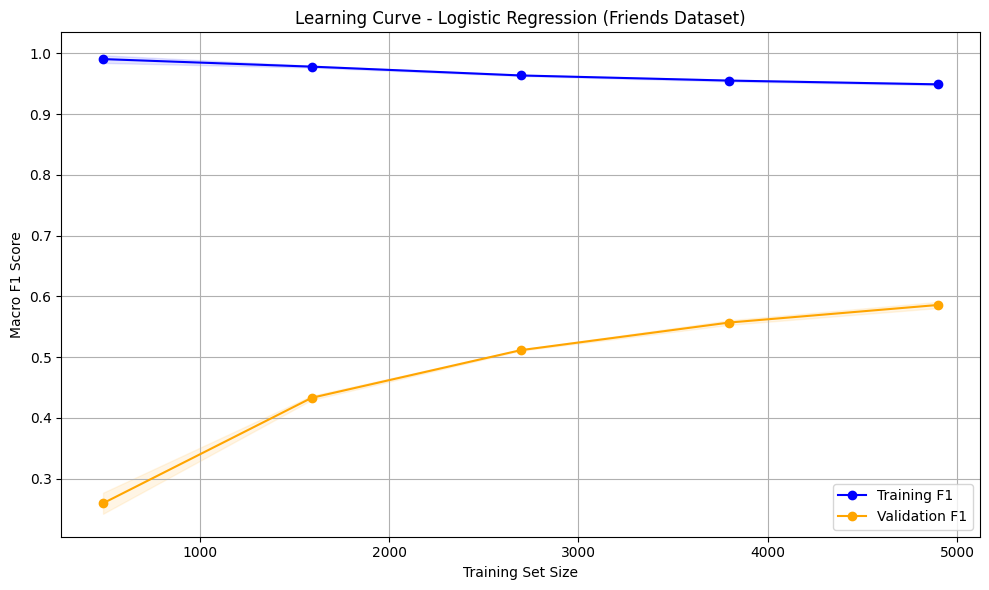

In [91]:
# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load the dataset
friends = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends.head())

# Keep only the relevant columns
friends_clean = friends[['processed_text', 'emotion']].copy()
friends_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean.isnull().sum())

# Drop rows with missing text or label
friends_clean.dropna(subset=['text', 'label'], inplace=True)
print(f"Step 4: Removing rows with missing information completed. Dataset size after removal: {len(friends_clean)}")

# Encode emotion labels
label_encoder = LabelEncoder()
friends_clean['label_encoded'] = label_encoder.fit_transform(friends_clean['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean['text'].astype(str),
    friends_clean['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# TF-IDF vectorizer with best config
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=50000, stop_words=None)

# Convert text data to TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Display feature shapes
print(f"Step 7: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

# Initialize the model
logreg_model = LogisticRegression(max_iter=500, random_state=42)

# Train on training data
logreg_model.fit(X_train_tfidf, y_train)

print("Step 8: Logistic Regression model trained successfully.")

# Predict on validation set
y_val_pred = logreg_model.predict(X_val_tfidf)

# Predict on test set
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 9: Model prediction completed for validation and test sets.")

# Validation set evaluation
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Step 10: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Macro F1 Score: {val_f1:.2f}")
print("Validation Classification Report:\n", val_report)

# Test set evaluation
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Step 11: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Macro F1 Score: {test_f1:.2f}")
print("Test Classification Report:\n", test_report)

# Confusion Matrix - Validation Set
print("Step 12: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)
plt.show()

# Confusion Matrix - Test Set
print("Step 12: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)
plt.show()

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Means and stds
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot learning curve
print("Step 13: Plot the Learning Curve")
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
plt.title("Learning Curve - Logistic Regression (Friends Dataset)")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Test

Step 1: New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


Step 2: Selected relevant columns from test dataset. Preview:


,text,label
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness
1,Thousands of model hopefuls from all over Asia...,happiness
2,But only the standout modeling talent were cho...,happiness
3,Prepare for an adventure of a lifetime,happiness
4,All I can say girls for this fierce fifth seas...,happiness


Step 3: Checking for missing values in test data:
text     0
label    0
dtype: int64
Remaining test rows after dropping missing: 860
Step 4: Converted one-hot labels into categorical labels. Preview:


,text,label,label_encoded
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,3
1,Thousands of model hopefuls from all over Asia...,happiness,3
2,But only the standout modeling talent were cho...,happiness,3
3,Prepare for an adventure of a lifetime,happiness,3
4,All I can say girls for this fierce fifth seas...,happiness,3


Test Dataset Accuracy: 0.33
Test Dataset Macro F1 Score: 0.24
Classification Report on Test Data:

              precision    recall  f1-score   support

       anger       0.08      0.32      0.13        53
     disgust       0.00      0.00      0.00         1
        fear       0.23      0.18      0.21        38
   happiness       0.67      0.33      0.44       391
     neutral       0.47      0.37      0.42       276
     sadness       0.14      0.22      0.17        65
    surprise       0.26      0.44      0.33        36

    accuracy                           0.33       860
   macro avg       0.26      0.27      0.24       860
weighted avg       0.49      0.33      0.38       860

Confusion Matrix for Test Data:


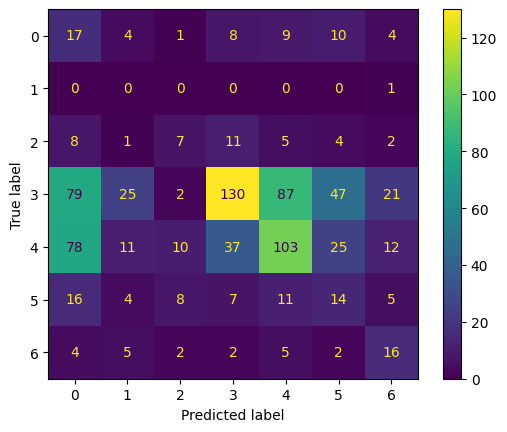

In [92]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("Step 1: New test dataset loaded successfully. Preview:")
display(df_test.head())

# Keep only the relevant columns
df_test_clean = df_test[['processed_text', 'emotion']].copy()
df_test_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm selection
print("Step 2: Selected relevant columns from test dataset. Preview:")
display(df_test_clean.head())

# Handle Missing Values (if any)
print("Step 3: Checking for missing values in test data:")
print(df_test_clean.isnull().sum())
df_test_clean.dropna(subset=['text', 'label'], inplace=True)

print(f"Remaining test rows after dropping missing: {len(df_test_clean)}")

# Encode emotion labels using the same label encoder used in training
df_test_clean['label_encoded'] = label_encoder.transform(df_test_clean['label'])

# Display preview after label encoding
print("Step 4: Converted one-hot labels into categorical labels. Preview:")
display(df_test_clean[['text', 'label', 'label_encoded']].head())

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_tfidf = vectorizer.transform(df_test_clean['text'].astype(str))

# Make Predictions Using the Trained Logistic Regression Model
y_test_pred = logreg_model.predict(X_test_tfidf)

# Evaluate Model Performance on Test Data
accuracy_test = accuracy_score(df_test_clean['label_encoded'], y_test_pred)
f1_test = f1_score(df_test_clean['label_encoded'], y_test_pred, average='macro')

print(f"Test Dataset Accuracy: {accuracy_test:.2f}")
print(f"Test Dataset Macro F1 Score: {f1_test:.2f}")

# Generate classification report
print("Classification Report on Test Data:\n")
print(classification_report(df_test_clean['label_encoded'], y_test_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for Test Data:")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, df_test_clean['label_encoded'])
plt.show()

## Iteration 3 - Hyperparameter Tuning

### Parameter grid for liblinear

In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
from scipy.sparse import vstack
import matplotlib.pyplot as plt

# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load the dataset
friends_df = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends_df.head())

# Keep only the relevant columns
friends_clean_df = friends_df[['processed_text', 'emotion']].copy()
friends_clean_df.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean_df.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean_df.isnull().sum())

# Drop rows with any missing values
friends_clean_df.dropna(subset=['text', 'label'], inplace=True)
print(f"Step 4: Removing missing values completed. Dataset size after removal: {len(friends_clean_df)}")

# Encode categorical labels as integers
label_encoder = LabelEncoder()
friends_clean_df['label_encoded'] = label_encoder.fit_transform(friends_clean_df['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean_df[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets (before vectorization to avoid data leakage)
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean_df['text'].astype(str),
    friends_clean_df['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean_df['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# TF-IDF Vectorization (Best Config from Previous Tuning)
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=50000, stop_words=None)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

# Combine training and validation sets for hyperparameter tuning
X_combined = vstack([X_train_tfidf, X_val_tfidf])
y_combined = pd.concat([y_train, y_val])

# Define parameter grid for liblinear only
param_grid_liblinear = {
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [500, 1000, 2000],
    'tol': [1e-3, 1e-4]
}

# Run Grid Search with Cross-Validation for liblinear
grid_search_liblinear = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid_liblinear,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_liblinear.fit(X_combined, y_combined)

# Output best parameters and score
best_logreg_model = grid_search_liblinear.best_estimator_
best_params = grid_search_liblinear.best_params_
best_score = grid_search_liblinear.best_score_

print("\n=== Best Logistic Regression Configuration (liblinear) ===")
print(f"Best Parameters: {best_params}")
print(f"Best Macro F1 Score from CV: {best_score:.4f}")

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing missing values completed. Dataset size after removal: 10500
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples
Fitting 3 folds for each of 96 candidates, totalling 288 fits

=== Step 10: Best Logistic Regression Configuration (liblinear) ===
Best Parameters: {'C': 10, 'class_weight': None, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear', 'tol': 0.001}
Best Macro F1 Score from CV: 0.6250


#### Train model

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing rows with missing information completed. Dataset size after removal: 10500
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples
Step 7: TF-IDF transformation completed. Feature shape (train): (7350, 50000)
Feature shape (validation): (1575, 50000)
Feature shape (test): (1575, 50000)
Step 8: Logistic Regression model trained successfully.
Step 9: Model prediction completed for validation and test sets.
Step 10: Validation Set Evaluation Completed.
Validation Accuracy: 0.66
Validation Macro F1 Score: 0.64
Validation Classification Report:
               precision    recall  f1-score   support

       anger       0.50      0.47      0.48       225
     disgust       0.89      0.92      0.90       225
        fear       0.81      0.93      0.87       225
   happiness       0.50      0.45      0.47       225
     neutral       0.36      0.27      0.31       225
     sadness       0.69      0.83      0.75       225
    surprise       0.71      0.

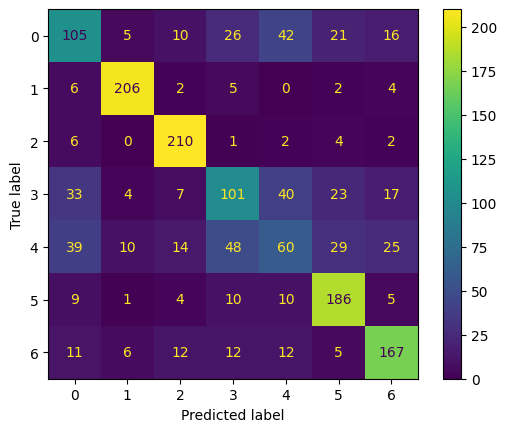

Step 12: Confusion Matrix for Test Set


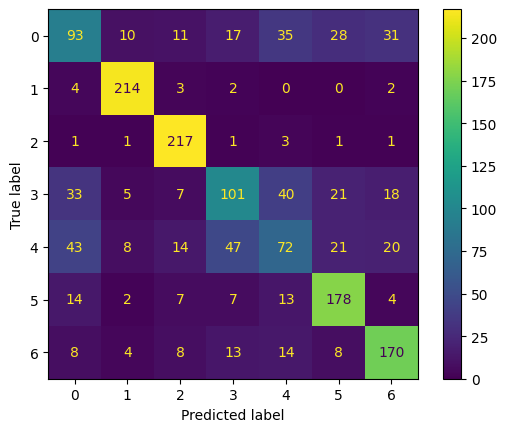

Step 13: Plot the Learning Curve


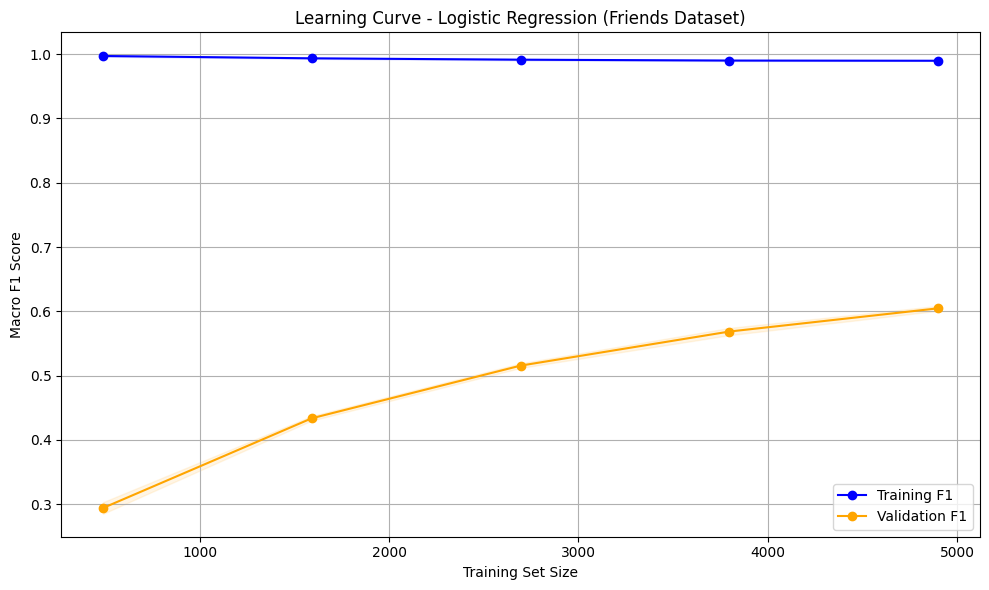

In [100]:
# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load the dataset
friends = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends.head())

# Keep only the relevant columns
friends_clean = friends[['processed_text', 'emotion']].copy()
friends_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean.isnull().sum())

# Drop rows with missing text or label
friends_clean.dropna(subset=['text', 'label'], inplace=True)

# Display result after removal
print(f"Step 4: Removing rows with missing information completed. Dataset size after removal: {len(friends_clean)}")

# Encode emotion labels
label_encoder = LabelEncoder()
friends_clean['label_encoded'] = label_encoder.fit_transform(friends_clean['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean['text'].astype(str),
    friends_clean['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# TF-IDF vectorizer with the best configuration
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=50000, stop_words=None)

# Convert text data to TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Display feature shapes
print(f"Step 7: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

# Initialize a Logistic Regression model using best found hyperparameters
logreg_model = LogisticRegression(
    C=10,
    class_weight=None,
    max_iter=500,
    penalty='l2',
    solver='liblinear',
    tol=0.001,
    random_state=42
)

# Train on training data
logreg_model.fit(X_train_tfidf, y_train)

print("Step 8: Logistic Regression model trained successfully.")

# Predict on validation set
y_val_pred = logreg_model.predict(X_val_tfidf)

# Predict on test set
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 9: Model prediction completed for validation and test sets.")

# Validation set evaluation
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Step 10: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Macro F1 Score: {val_f1:.2f}")
print("Validation Classification Report:\n", val_report)

# Test set evaluation
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Step 11: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Macro F1 Score: {test_f1:.2f}")
print("Test Classification Report:\n", test_report)

# Confusion Matrix - Validation Set
print("Step 12: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)
plt.show()

# Confusion Matrix - Test Set
print("Step 12: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)
plt.show()

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Means and stds
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot learning curve
print("Step 13: Plot the Learning Curve")
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
plt.title("Learning Curve - Logistic Regression (Friends Dataset)")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Test

Step 1: New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


Step 2: Selected relevant columns from test dataset. Preview:


,text,label
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness
1,Thousands of model hopefuls from all over Asia...,happiness
2,But only the standout modeling talent were cho...,happiness
3,Prepare for an adventure of a lifetime,happiness
4,All I can say girls for this fierce fifth seas...,happiness


Step 3: Checking for missing values in test data:
text     0
label    0
dtype: int64
Remaining test rows after dropping missing: 860
Step 4: Converted one-hot labels into categorical labels. Preview:


,text,label,label_encoded
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,3
1,Thousands of model hopefuls from all over Asia...,happiness,3
2,But only the standout modeling talent were cho...,happiness,3
3,Prepare for an adventure of a lifetime,happiness,3
4,All I can say girls for this fierce fifth seas...,happiness,3


Test Dataset Accuracy: 0.34
Test Dataset Macro F1 Score: 0.24
Classification Report on Test Data:

              precision    recall  f1-score   support

       anger       0.10      0.40      0.16        53
     disgust       0.00      0.00      0.00         1
        fear       0.26      0.16      0.20        38
   happiness       0.66      0.36      0.47       391
     neutral       0.42      0.34      0.38       276
     sadness       0.12      0.17      0.14        65
    surprise       0.29      0.50      0.37        36

    accuracy                           0.34       860
   macro avg       0.27      0.27      0.24       860
weighted avg       0.48      0.34      0.38       860

Confusion Matrix for Test Data:


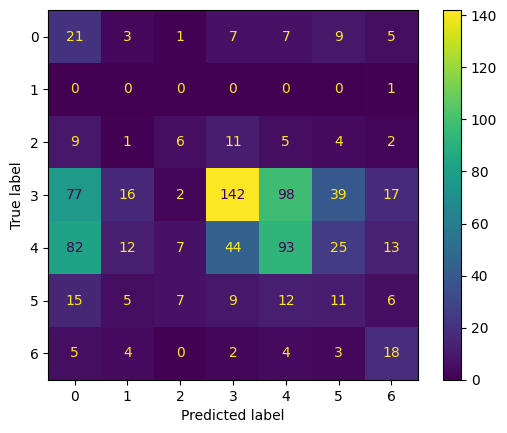

In [101]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("Step 1: New test dataset loaded successfully. Preview:")
display(df_test.head())

# Keep only the relevant columns
df_test_clean = df_test[['processed_text', 'emotion']].copy()
df_test_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm selection
print("Step 2: Selected relevant columns from test dataset. Preview:")
display(df_test_clean.head())

# Handle Missing Values (if any)
print("Step 3: Checking for missing values in test data:")
print(df_test_clean.isnull().sum())
df_test_clean.dropna(subset=['text', 'label'], inplace=True)

print(f"Remaining test rows after dropping missing: {len(df_test_clean)}")

# Encode emotion labels using the same label encoder used in training
df_test_clean['label_encoded'] = label_encoder.transform(df_test_clean['label'])

# Display preview after label encoding
print("Step 4: Converted one-hot labels into categorical labels. Preview:")
display(df_test_clean[['text', 'label', 'label_encoded']].head())

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_tfidf = vectorizer.transform(df_test_clean['text'].astype(str))

# Make Predictions Using the Trained Logistic Regression Model
y_test_pred = logreg_model.predict(X_test_tfidf)

# Evaluate Model Performance on Test Data
accuracy_test = accuracy_score(df_test_clean['label_encoded'], y_test_pred)
f1_test = f1_score(df_test_clean['label_encoded'], y_test_pred, average='macro')

print(f"Test Dataset Accuracy: {accuracy_test:.2f}")
print(f"Test Dataset Macro F1 Score: {f1_test:.2f}")

# Generate classification report
print("Classification Report on Test Data:\n")
print(classification_report(df_test_clean['label_encoded'], y_test_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for Test Data:")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, df_test_clean['label_encoded'])
plt.show()

### Parameter grid for saga

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
from scipy.sparse import vstack
import matplotlib.pyplot as plt

# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load the dataset
friends_df = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends_df.head())

# Keep only the relevant columns
friends_clean_df = friends_df[['processed_text', 'emotion']].copy()
friends_clean_df.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean_df.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean_df.isnull().sum())

# Drop rows with any missing values
friends_clean_df.dropna(subset=['text', 'label'], inplace=True)
print(f"Step 4: Removing missing values completed. Dataset size after removal: {len(friends_clean_df)}")

# Encode categorical labels as integers
label_encoder = LabelEncoder()
friends_clean_df['label_encoded'] = label_encoder.fit_transform(friends_clean_df['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean_df[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets (before vectorization to avoid data leakage)
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean_df['text'].astype(str),
    friends_clean_df['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean_df['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# TF-IDF Vectorization (Best Config from Previous Tuning)
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=50000, stop_words=None)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

# Combine training and validation sets for hyperparameter tuning
X_combined = vstack([X_train_tfidf, X_val_tfidf])
y_combined = pd.concat([y_train, y_val])

# Define parameter grid for saga only
param_grid_saga = {
    'solver': ['saga'],
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [500, 1000, 2000],
    'tol': [1e-3, 1e-4]
}

# Run Grid Search with Cross-Validation for saga
grid_search_saga = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid_saga,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_saga.fit(X_combined, y_combined)

# Output best parameters and score
best_logreg_model = grid_search_saga.best_estimator_
best_params = grid_search_saga.best_params_
best_score = grid_search_saga.best_score_

print("\n=== Best Logistic Regression Configuration (saga) ===")
print(f"Best Parameters: {best_params}")
print(f"Best Macro F1 Score from CV: {best_score:.4f}")

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing missing values completed. Dataset size after removal: 10500
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples
Fitting 3 folds for each of 48 candidates, totalling 144 fits

=== Step 10: Best Logistic Regression Configuration (saga) ===
Best Parameters: {'C': 10, 'class_weight': None, 'max_iter': 500, 'penalty': 'l2', 'solver': 'saga', 'tol': 0.001}
Best Macro F1 Score from CV: 0.6308


#### Train model

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing rows with missing information completed. Dataset size after removal: 10500
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples
Step 7: TF-IDF transformation completed. Feature shape (train): (7350, 50000)
Feature shape (validation): (1575, 50000)
Feature shape (test): (1575, 50000)
Step 8: Logistic Regression model trained successfully.
Step 9: Model prediction completed for validation and test sets.
Step 10: Validation Set Evaluation Completed.
Validation Accuracy: 0.66
Validation Macro F1 Score: 0.65
Validation Classification Report:
               precision    recall  f1-score   support

       anger       0.48      0.48      0.48       225
     disgust       0.90      0.92      0.91       225
        fear       0.83      0.93      0.88       225
   happiness       0.50      0.45      0.47       225
     neutral       0.35      0.28      0.31       225
     sadness       0.71      0.83      0.76       225
    surprise       0.71      0.

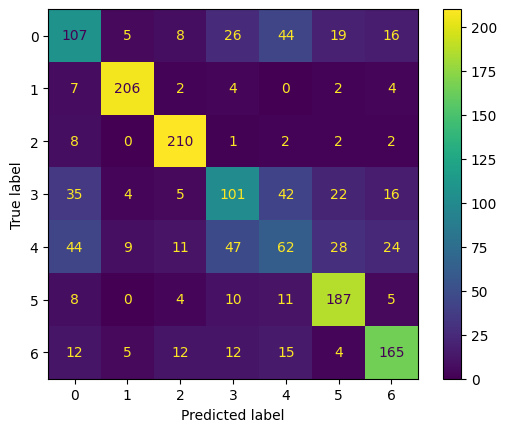

Step 12: Confusion Matrix for Test Set


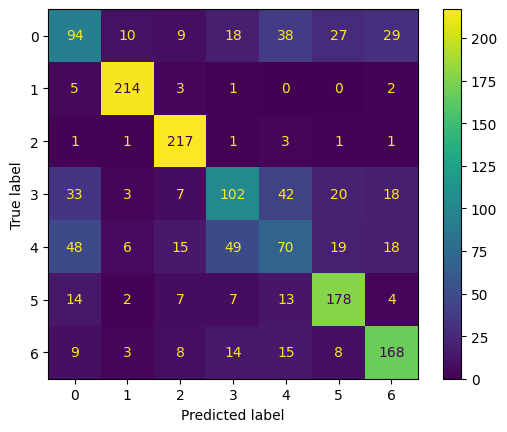

Step 13: Plot the Learning Curve


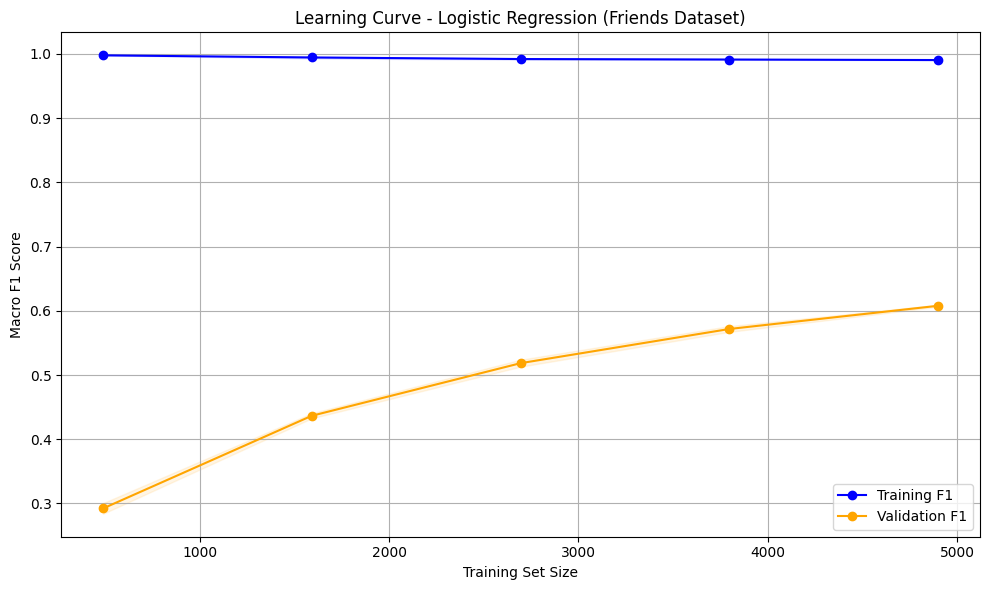

In [102]:
# File path 

data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load the dataset
friends = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends.head())

# Keep only the relevant columns
friends_clean = friends[['processed_text', 'emotion']].copy()
friends_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean.isnull().sum())

# Drop rows with missing text or label
friends_clean.dropna(subset=['text', 'label'], inplace=True)

# Display result after removal
print(f"Step 4: Removing rows with missing information completed. Dataset size after removal: {len(friends_clean)}")

# Encode emotion labels
label_encoder = LabelEncoder()
friends_clean['label_encoded'] = label_encoder.fit_transform(friends_clean['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean['text'].astype(str),
    friends_clean['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# TF-IDF vectorizer with the best configuration
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=50000, stop_words=None)

# Convert text data to TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Display feature shapes
print(f"Step 7: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

# Initialize a Logistic Regression model using best found saga hyperparameters
logreg_model = LogisticRegression(
    C=10,
    class_weight=None,
    max_iter=500,
    penalty='l2',
    solver='saga',
    tol=0.001,
    random_state=42
)

# Train on training data
logreg_model.fit(X_train_tfidf, y_train)

print("Step 8: Logistic Regression model trained successfully.")

# Predict on validation set
y_val_pred = logreg_model.predict(X_val_tfidf)

# Predict on test set
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 9: Model prediction completed for validation and test sets.")

# Validation set evaluation
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Step 10: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Macro F1 Score: {val_f1:.2f}")
print("Validation Classification Report:\n", val_report)

# Test set evaluation
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Step 11: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Macro F1 Score: {test_f1:.2f}")
print("Test Classification Report:\n", test_report)

# Confusion Matrix - Validation Set
print("Step 12: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)
plt.show()

# Confusion Matrix - Test Set
print("Step 12: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)
plt.show()

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Means and stds
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot learning curve
print("Step 13: Plot the Learning Curve")
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
plt.title("Learning Curve - Logistic Regression (Friends Dataset)")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Test

Step 1: New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


Step 2: Selected relevant columns from test dataset. Preview:


,text,label
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness
1,Thousands of model hopefuls from all over Asia...,happiness
2,But only the standout modeling talent were cho...,happiness
3,Prepare for an adventure of a lifetime,happiness
4,All I can say girls for this fierce fifth seas...,happiness


Step 3: Checking for missing values in test data:
text     0
label    0
dtype: int64
Remaining test rows after dropping missing: 860
Step 4: Converted one-hot labels into categorical labels. Preview:


,text,label,label_encoded
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,3
1,Thousands of model hopefuls from all over Asia...,happiness,3
2,But only the standout modeling talent were cho...,happiness,3
3,Prepare for an adventure of a lifetime,happiness,3
4,All I can say girls for this fierce fifth seas...,happiness,3


Test Dataset Accuracy: 0.34
Test Dataset Macro F1 Score: 0.25
Classification Report on Test Data:

              precision    recall  f1-score   support

       anger       0.10      0.42      0.16        53
     disgust       0.00      0.00      0.00         1
        fear       0.30      0.16      0.21        38
   happiness       0.65      0.37      0.47       391
     neutral       0.42      0.34      0.38       276
     sadness       0.11      0.15      0.13        65
    surprise       0.29      0.50      0.37        36

    accuracy                           0.34       860
   macro avg       0.27      0.28      0.25       860
weighted avg       0.47      0.34      0.38       860

Confusion Matrix for Test Data:


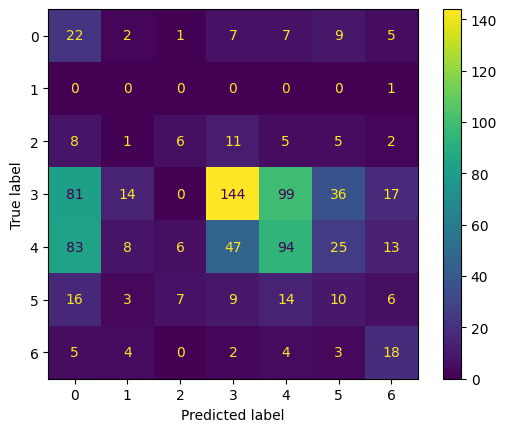

In [103]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("Step 1: New test dataset loaded successfully. Preview:")
display(df_test.head())

# Keep only the relevant columns
df_test_clean = df_test[['processed_text', 'emotion']].copy()
df_test_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm selection
print("Step 2: Selected relevant columns from test dataset. Preview:")
display(df_test_clean.head())

# Handle Missing Values (if any)
print("Step 3: Checking for missing values in test data:")
print(df_test_clean.isnull().sum())
df_test_clean.dropna(subset=['text', 'label'], inplace=True)

print(f"Remaining test rows after dropping missing: {len(df_test_clean)}")

# Encode emotion labels using the same label encoder used in training
df_test_clean['label_encoded'] = label_encoder.transform(df_test_clean['label'])

# Display preview after label encoding
print("Step 4: Converted one-hot labels into categorical labels. Preview:")
display(df_test_clean[['text', 'label', 'label_encoded']].head())

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_tfidf = vectorizer.transform(df_test_clean['text'].astype(str))

# Make Predictions Using the Trained Logistic Regression Model
y_test_pred = logreg_model.predict(X_test_tfidf)

# Evaluate Model Performance on Test Data
accuracy_test = accuracy_score(df_test_clean['label_encoded'], y_test_pred)
f1_test = f1_score(df_test_clean['label_encoded'], y_test_pred, average='macro')

print(f"Test Dataset Accuracy: {accuracy_test:.2f}")
print(f"Test Dataset Macro F1 Score: {f1_test:.2f}")

# Generate classification report
print("Classification Report on Test Data:\n")
print(classification_report(df_test_clean['label_encoded'], y_test_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for Test Data:")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, df_test_clean['label_encoded'])
plt.show()

### Parameter grid for lbfgs

In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
from scipy.sparse import vstack
import matplotlib.pyplot as plt

# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load the dataset
friends_df = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends_df.head())

# Keep only the relevant columns
friends_clean_df = friends_df[['processed_text', 'emotion']].copy()
friends_clean_df.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean_df.head())

# Check for missing values
print("Missing values in each column:")
print(friends_clean_df.isnull().sum())

# Drop rows with any missing values
friends_clean_df.dropna(subset=['text', 'label'], inplace=True)
print(f"Step 3: Removing missing values completed. Dataset size after removal: {len(friends_clean_df)}")

# Encode emotion labels
label_encoder = LabelEncoder()
friends_clean_df['label_encoded'] = label_encoder.fit_transform(friends_clean_df['label'])

# Display the first few rows to verify the conversion
print("Step 4: Converted emotion labels into categorical labels. Preview:")
display(friends_clean_df[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean_df['text'].astype(str),
    friends_clean_df['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean_df['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 5: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# TF-IDF Vectorization (Best Config from Previous Tuning)
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=50000, stop_words=None)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

# Combine training and validation sets for hyperparameter tuning
X_combined = vstack([X_train_tfidf, X_val_tfidf])
y_combined = pd.concat([y_train, y_val])

# Define parameter grid for lbfgs only
param_grid_lbfgs = {
    'solver': ['lbfgs'],
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [500, 1000, 2000],
    'tol': [1e-3, 1e-4]
}

# Run Grid Search with Cross-Validation for lbfgs
grid_search_lbfgs = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid_lbfgs,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_lbfgs.fit(X_combined, y_combined)

# Output best parameters and score
best_logreg_model = grid_search_lbfgs.best_estimator_
best_params = grid_search_lbfgs.best_params_
best_score = grid_search_lbfgs.best_score_

print("\n=== Step 9: Best Logistic Regression Configuration (lbfgs) ===")
print(f"Best Parameters: {best_params}")
print(f"Best Macro F1 Score from CV: {best_score:.4f}")

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Missing values in each column:
text     0
label    0
dtype: int64
Step 3: Removing missing values completed. Dataset size after removal: 10500
Step 4: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 5: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples
Fitting 3 folds for each of 48 candidates, totalling 144 fits

=== Step 9: Best Logistic Regression Configuration (lbfgs) ===
Best Parameters: {'C': 10, 'class_weight': None, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.001}
Best Macro F1 Score from CV: 0.6313


#### Train model

Step 1: Dataset loaded successfully. Preview:


,text,emotion,emotion_code,processed_text
0,"Oh, did you catch him?!",surprise,4,"Oh , did you catch him ? !"
1,Oh man. Please tell me one of 'em is Ma.,disgust,5,Oh man . Please tell me one of 'em is Ma .
2,"Look, look at your man, Ewing. Nice shot. You ...",disgust,5,"Look , look at your man , Ewing . Nice shot . ..."
3,"I’m sorry Chandler, y’know you are such a swee...",sadness,1,"I am sorry Chandler , you know you are such a ..."
4,You bug me.,disgust,5,You bug me .


Step 2: Selected relevant columns. Preview:


,text,label
0,"Oh , did you catch him ? !",surprise
1,Oh man . Please tell me one of 'em is Ma .,disgust
2,"Look , look at your man , Ewing . Nice shot . ...",disgust
3,"I am sorry Chandler , you know you are such a ...",sadness
4,You bug me .,disgust


Step 3: Checking for missing values:
text     0
label    0
dtype: int64
Step 4: Removing rows with missing information completed. Dataset size after removal: 10500
Step 5: Converted emotion labels into categorical labels. Preview:


,text,label,label_encoded
0,"Oh , did you catch him ? !",surprise,6
1,Oh man . Please tell me one of 'em is Ma .,disgust,1
2,"Look , look at your man , Ewing . Nice shot . ...",disgust,1
3,"I am sorry Chandler , you know you are such a ...",sadness,5
4,You bug me .,disgust,1


Step 6: Data successfully split into training, validation, and testing sets.
Training set size: 7350 samples
Validation set size: 1575 samples
Testing set size: 1575 samples
Step 7: TF-IDF transformation completed. Feature shape (train): (7350, 50000)
Feature shape (validation): (1575, 50000)
Feature shape (test): (1575, 50000)
Step 8: Logistic Regression model trained successfully.
Step 9: Model prediction completed for validation and test sets.
Step 10: Validation Set Evaluation Completed.
Validation Accuracy: 0.66
Validation Macro F1 Score: 0.65
Validation Classification Report:
               precision    recall  f1-score   support

       anger       0.47      0.46      0.46       225
     disgust       0.90      0.91      0.91       225
        fear       0.83      0.93      0.88       225
   happiness       0.52      0.45      0.48       225
     neutral       0.36      0.28      0.31       225
     sadness       0.69      0.84      0.76       225
    surprise       0.70      0.

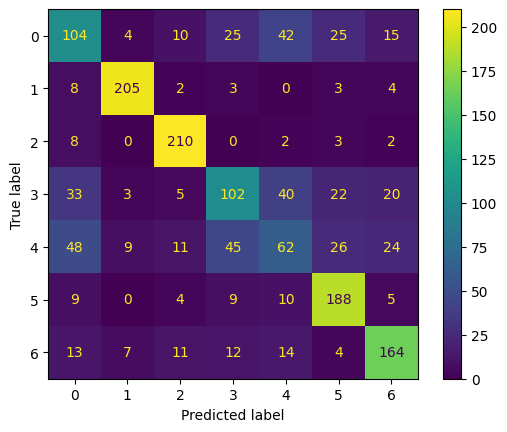

Step 12: Confusion Matrix for Test Set


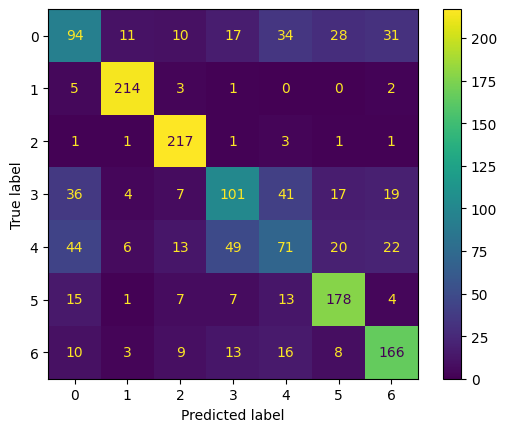

Step 13: Plot the Learning Curve


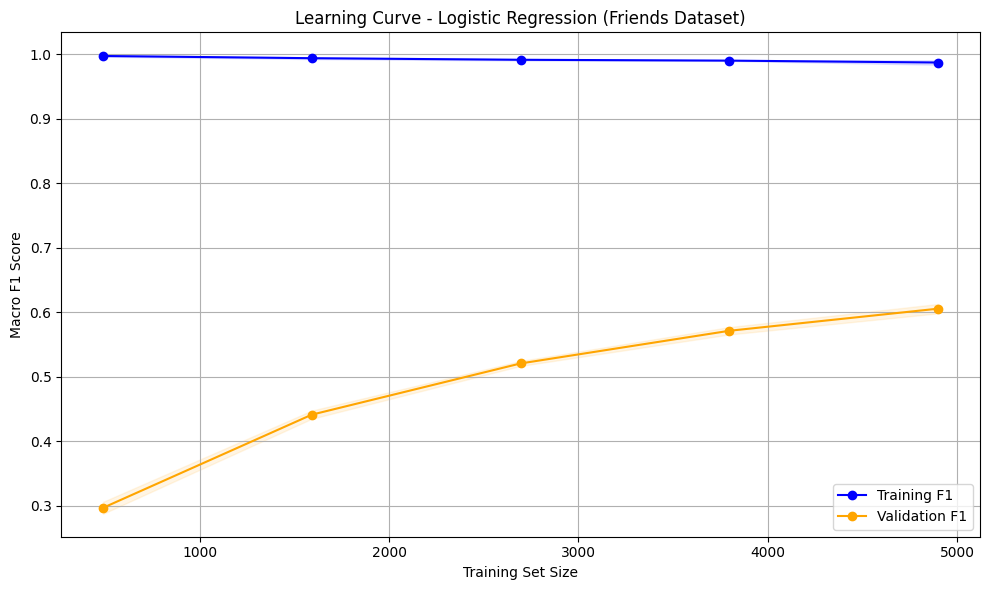

In [104]:
# File path 
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\friends_balanced.csv"

# Load the dataset
friends = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(friends.head())

# Keep only the relevant columns
friends_clean = friends[['processed_text', 'emotion']].copy()
friends_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm the selection
print("Step 2: Selected relevant columns. Preview:")
display(friends_clean.head())

# Check for missing values
print("Step 3: Checking for missing values:")
print(friends_clean.isnull().sum())

# Drop rows with missing text or label
friends_clean.dropna(subset=['text', 'label'], inplace=True)

# Display result after removal
print(f"Step 4: Removing rows with missing information completed. Dataset size after removal: {len(friends_clean)}")

# Encode emotion labels
label_encoder = LabelEncoder()
friends_clean['label_encoded'] = label_encoder.fit_transform(friends_clean['label'])

# Display the first few rows to verify the conversion
print("Step 5: Converted emotion labels into categorical labels. Preview:")
display(friends_clean[['text', 'label', 'label_encoded']].head())

# Split data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(
    friends_clean['text'].astype(str),
    friends_clean['label_encoded'],
    test_size=0.3,
    random_state=42,
    stratify=friends_clean['label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Display dataset split details
print("Step 6: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# TF-IDF vectorizer with the best configuration
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=50000, stop_words=None)

# Convert text data to TF-IDF features
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Display feature shapes
print(f"Step 7: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

# Initialize a Logistic Regression model using best found lbfgs hyperparameters
logreg_model = LogisticRegression(
    C=10,
    class_weight=None,
    max_iter=500,
    penalty='l2',
    solver='lbfgs',
    tol=0.001,
    random_state=42
)

# Train on training data
logreg_model.fit(X_train_tfidf, y_train)

print("Step 8: Logistic Regression model trained successfully.")

# Predict on validation set
y_val_pred = logreg_model.predict(X_val_tfidf)

# Predict on test set
y_test_pred = logreg_model.predict(X_test_tfidf)

print("Step 9: Model prediction completed for validation and test sets.")

# Validation set evaluation
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Step 10: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Validation Macro F1 Score: {val_f1:.2f}")
print("Validation Classification Report:\n", val_report)

# Test set evaluation
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Step 11: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Macro F1 Score: {test_f1:.2f}")
print("Test Classification Report:\n", test_report)

# Confusion Matrix - Validation Set
print("Step 12: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_val_tfidf, y_val)
plt.show()

# Confusion Matrix - Test Set
print("Step 12: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, y_test)
plt.show()

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Means and stds
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot learning curve
print("Step 13: Plot the Learning Curve")
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
plt.title("Learning Curve - Logistic Regression (Friends Dataset)")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Test

Step 1: New test dataset loaded successfully. Preview:


,text,emotion,emotion_code,sub-emotion,processed_text
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,0,excitement,Hang on to your seats cuz Asia's Next Top Mode...
1,Thousands of model hopefuls from all over Asia...,happiness,0,optimism,Thousands of model hopefuls from all over Asia...
2,But only the standout modeling talent were cho...,happiness,0,pride,But only the standout modeling talent were cho...
3,Prepare for an adventure of a lifetime,happiness,0,excitement,Prepare for an adventure of a lifetime
4,All I can say girls for this fierce fifth seas...,happiness,0,excitement,All I can say girls for this fierce fifth seas...


Step 2: Selected relevant columns from test dataset. Preview:


,text,label
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness
1,Thousands of model hopefuls from all over Asia...,happiness
2,But only the standout modeling talent were cho...,happiness
3,Prepare for an adventure of a lifetime,happiness
4,All I can say girls for this fierce fifth seas...,happiness


Step 3: Checking for missing values in test data:
text     0
label    0
dtype: int64
Remaining test rows after dropping missing: 860
Step 4: Converted one-hot labels into categorical labels. Preview:


,text,label,label_encoded
0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,3
1,Thousands of model hopefuls from all over Asia...,happiness,3
2,But only the standout modeling talent were cho...,happiness,3
3,Prepare for an adventure of a lifetime,happiness,3
4,All I can say girls for this fierce fifth seas...,happiness,3


Test Dataset Accuracy: 0.33
Test Dataset Macro F1 Score: 0.24
Classification Report on Test Data:

              precision    recall  f1-score   support

       anger       0.09      0.40      0.15        53
     disgust       0.00      0.00      0.00         1
        fear       0.30      0.16      0.21        38
   happiness       0.64      0.35      0.45       391
     neutral       0.42      0.34      0.38       276
     sadness       0.12      0.17      0.14        65
    surprise       0.30      0.50      0.37        36

    accuracy                           0.33       860
   macro avg       0.27      0.27      0.24       860
weighted avg       0.47      0.33      0.37       860

Confusion Matrix for Test Data:


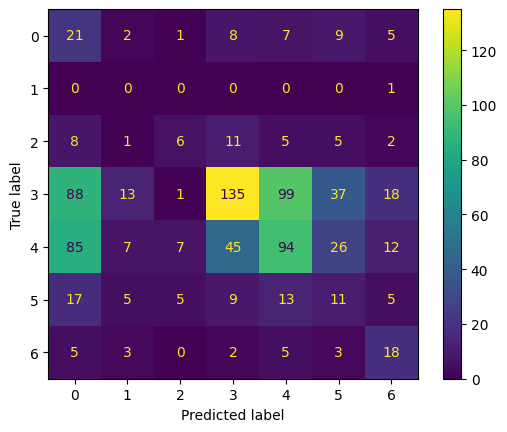

In [105]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 5 - Model Iterations\Logistic Regression\Data\test.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("Step 1: New test dataset loaded successfully. Preview:")
display(df_test.head())

# Keep only the relevant columns
df_test_clean = df_test[['processed_text', 'emotion']].copy()
df_test_clean.rename(columns={'processed_text': 'text', 'emotion': 'label'}, inplace=True)

# Confirm selection
print("Step 2: Selected relevant columns from test dataset. Preview:")
display(df_test_clean.head())

# Handle Missing Values (if any)
print("Step 3: Checking for missing values in test data:")
print(df_test_clean.isnull().sum())
df_test_clean.dropna(subset=['text', 'label'], inplace=True)

print(f"Remaining test rows after dropping missing: {len(df_test_clean)}")

# Encode emotion labels using the same label encoder used in training
df_test_clean['label_encoded'] = label_encoder.transform(df_test_clean['label'])

# Display preview after label encoding
print("Step 4: Converted one-hot labels into categorical labels. Preview:")
display(df_test_clean[['text', 'label', 'label_encoded']].head())

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_tfidf = vectorizer.transform(df_test_clean['text'].astype(str))

# Make Predictions Using the Trained Logistic Regression Model
y_test_pred = logreg_model.predict(X_test_tfidf)

# Evaluate Model Performance on Test Data
accuracy_test = accuracy_score(df_test_clean['label_encoded'], y_test_pred)
f1_test = f1_score(df_test_clean['label_encoded'], y_test_pred, average='macro')

print(f"Test Dataset Accuracy: {accuracy_test:.2f}")
print(f"Test Dataset Macro F1 Score: {f1_test:.2f}")

# Generate classification report
print("Classification Report on Test Data:\n")
print(classification_report(df_test_clean['label_encoded'], y_test_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for Test Data:")
ConfusionMatrixDisplay.from_estimator(logreg_model, X_test_tfidf, df_test_clean['label_encoded'])
plt.show()